In [ ]:

%%bash
pip install scikit-image -q


NEWRELIC: 2025-12-03 13:30:05 (82) - New Relic could not start because the newrelic-admin script was

 called from a Python installation that is different from the Python installation that is currently 

running. To fix this problem, call the newrelic-admin script from the Python installation that is cu

rrently running (details below).

newrelic-admin Python directory: None
current Python directory: '/

app/miniconda'
newrelic-admin Python version: None
current Python version: '3.12'


...

numpydoc 1.5.0 requires sphinx>=4.2, but you have sphinx 3.5.3 which is incompatible.


 --upgrade to force replacement.

/.local_packages/numpy.libs already exists. Specify --upgrade to force replacement.
[3

ists. Specify --upgrade to force replacement.

orkspace_path/.local_packages/bin already exists. Specify --upgrade to force replacement.


In [ ]:

# Import necessary libraries
import numpy as np
import os
from PIL import Image
import pywt
from skimage.restoration import denoise_tv_chambolle
from skimage.filters import rank
from skimage.morphology import disk
from scipy.ndimage import sobel
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt
import time

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"PyWavelets version: {pywt.__version__}")


Libraries imported successfully
NumPy version: 1.26.4
PyWavelets version: 1.8.0


In [ ]:

# Step 1: Select the same subset of 30 images (15 benign, 15 malignant)
# Using fixed random seed for reproducibility

# Get list of benign and malignant images
benign_dir = 'Dataset_BUSI_with_GT/benign/'
malignant_dir = 'Dataset_BUSI_with_GT/malignant/'

# Get all image files (excluding masks)
benign_files = sorted([f for f in os.listdir(benign_dir) if f.endswith('.png') and '_mask' not in f])
malignant_files = sorted([f for f in os.listdir(malignant_dir) if f.endswith('.png') and '_mask' not in f])

print(f"Total benign images: {len(benign_files)}")
print(f"Total malignant images: {len(malignant_files)}")

# Use same random state for reproducibility
np.random.seed(42)
selected_benign_indices = np.random.choice(len(benign_files), 15, replace=False)
selected_malignant_indices = np.random.choice(len(malignant_files), 15, replace=False)

selected_benign = [benign_files[i] for i in sorted(selected_benign_indices)]
selected_malignant = [malignant_files[i] for i in sorted(selected_malignant_indices)]

print(f"\nSelected {len(selected_benign)} benign images")
print(f"Selected {len(selected_malignant)} malignant images")
print(f"Total selected: {len(selected_benign) + len(selected_malignant)}")


Total benign images: 437
Total malignant images: 210

Selected 15 benign images
Selected 15 malignant images
Total selected: 30


In [ ]:

# Step 2: Load and preprocess images (resize to 128x128, convert to grayscale, normalize)
def load_and_preprocess_image(filepath, target_size=(128, 128)):
    """Load image, convert to grayscale, resize, and normalize to [0, 1]"""
    img = Image.open(filepath).convert('L')  # Convert to grayscale
    img = img.resize(target_size, Image.BILINEAR)  # Resize
    img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize to [0, 1]
    return img_array

# Load all 30 images
images = []
image_labels = []

for i, filename in enumerate(selected_benign):
    filepath = os.path.join(benign_dir, filename)
    img = load_and_preprocess_image(filepath)
    images.append(img)
    image_labels.append(f'benign_{i+1}')

for i, filename in enumerate(selected_malignant):
    filepath = os.path.join(malignant_dir, filename)
    img = load_and_preprocess_image(filepath)
    images.append(img)
    image_labels.append(f'malignant_{i+1}')

images = np.array(images)
print(f"Loaded {len(images)} images with shape: {images.shape}")
print(f"Value range: [{images.min():.3f}, {images.max():.3f}]")


Loaded 30 images with shape: (30, 128, 128)
Value range: [0.000, 1.000]


In [ ]:

# Step 3: Generate compressed sensing measurements
# Using 30% sampling rate with fixed random seed (42)

def generate_cs_measurements(images, sampling_rate=0.30, snr_db=25, seed=42):
    """
    Generate compressed sensing measurements with Gaussian measurement matrix and noise
    
    Parameters:
    - images: array of shape (n_images, height, width)
    - sampling_rate: fraction of measurements to take (0.30 = 30%)
    - snr_db: signal-to-noise ratio in decibels
    - seed: random seed for reproducibility
    
    Returns:
    - measurement_vectors: list of measurement vectors y
    - measurement_matrix: the Gaussian measurement matrix Phi
    """
    np.random.seed(seed)
    
    n_images, height, width = images.shape
    n = height * width  # Total pixels per image
    m = int(sampling_rate * n)  # Number of measurements
    
    print(f"Image size: {height}x{width} = {n} pixels")
    print(f"Sampling rate: {sampling_rate*100}%")
    print(f"Number of measurements: {m} (out of {n})")
    
    # Generate random Gaussian measurement matrix
    Phi = np.random.randn(m, n) / np.sqrt(m)
    
    # Generate measurements for all images
    measurement_vectors = []
    
    for i, img in enumerate(images):
        # Flatten image to vector
        x = img.flatten()
        
        # Generate clean measurements
        y_clean = Phi @ x
        
        # Add Gaussian noise to achieve target SNR
        signal_power = np.mean(y_clean ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = np.random.randn(m) * np.sqrt(noise_power)
        
        y_noisy = y_clean + noise
        measurement_vectors.append(y_noisy)
    
    print(f"Generated {len(measurement_vectors)} measurement vectors")
    
    return measurement_vectors, Phi

# Generate CS measurements
measurement_vectors, Phi = generate_cs_measurements(images, sampling_rate=0.30, snr_db=25, seed=42)
print(f"Measurement matrix shape: {Phi.shape}")
print(f"Each measurement vector shape: {measurement_vectors[0].shape}")


Image size: 128x128 = 16384 pixels
Sampling rate: 30.0%
Number of measurements: 4915 (out of 16384)


Generated 30 measurement vectors
Measurement matrix shape: (4915, 16384)
Each measurement vector shape: (4915,)


In [ ]:

# Step 4: Implement helper functions for HASA-ISTA algorithm

def compute_local_entropy(img, window_size=5):
    """
    Compute local entropy map using a sliding window
    
    Parameters:
    - img: 2D image array
    - window_size: size of the local window (odd number)
    
    Returns:
    - entropy_map: local entropy at each pixel
    """
    from scipy.stats import entropy as scipy_entropy
    
    def local_entropy_func(values):
        # Compute histogram-based entropy for local window
        hist, _ = np.histogram(values, bins=10, range=(0, 1), density=True)
        hist = hist + 1e-10  # Avoid log(0)
        return scipy_entropy(hist)
    
    # Apply generic filter for local entropy calculation
    entropy_map = generic_filter(img, local_entropy_func, size=window_size, mode='reflect')
    return entropy_map

def compute_gradient_magnitude(img):
    """
    Compute gradient magnitude map using Sobel operator
    
    Parameters:
    - img: 2D image array
    
    Returns:
    - gradient_map: gradient magnitude at each pixel
    """
    grad_x = sobel(img, axis=0)
    grad_y = sobel(img, axis=1)
    gradient_map = np.sqrt(grad_x**2 + grad_y**2)
    return gradient_map

def normalize_map(map_array):
    """
    Normalize map to [0, 1] range
    """
    map_min = map_array.min()
    map_max = map_array.max()
    if map_max - map_min > 1e-10:
        return (map_array - map_min) / (map_max - map_min)
    else:
        return np.ones_like(map_array)

print("Helper functions defined successfully")


Helper functions defined successfully


In [ ]:

# Step 5: Implement wavelet soft-thresholding proximal operator

def wavelet_soft_threshold(img, threshold, wavelet='db4', level=3):
    """
    Apply soft-thresholding in wavelet domain (proximal operator for L1 norm)
    
    Parameters:
    - img: 2D image array
    - threshold: threshold value (can be scalar or spatially-varying)
    - wavelet: wavelet type (default 'db4')
    - level: decomposition level
    
    Returns:
    - denoised image
    """
    # Perform wavelet decomposition
    coeffs = pywt.wavedec2(img, wavelet, level=level)
    
    # Apply soft-thresholding to detail coefficients
    # coeffs[0] is the approximation, coeffs[1:] are details
    coeffs_thresh = [coeffs[0]]  # Keep approximation as is
    
    for i in range(1, len(coeffs)):
        # Soft-thresholding for each detail level
        cH, cV, cD = coeffs[i]
        
        # If threshold is spatially-varying, use mean value for wavelet domain
        if isinstance(threshold, np.ndarray):
            thresh_val = np.mean(threshold)
        else:
            thresh_val = threshold
        
        cH_thresh = pywt.threshold(cH, thresh_val, mode='soft')
        cV_thresh = pywt.threshold(cV, thresh_val, mode='soft')
        cD_thresh = pywt.threshold(cD, thresh_val, mode='soft')
        
        coeffs_thresh.append((cH_thresh, cV_thresh, cD_thresh))
    
    # Reconstruct image
    img_recon = pywt.waverec2(coeffs_thresh, wavelet)
    
    # Ensure output has same shape as input
    img_recon = img_recon[:img.shape[0], :img.shape[1]]
    
    return img_recon

print("Wavelet soft-thresholding function defined")


Wavelet soft-thresholding function defined


In [ ]:

# Step 6: Implement the main HASA-ISTA algorithm

def hasa_ista_reconstruct(y, Phi, alpha=0.001, lambda_w=0.01, lambda_tv=0.01, 
                          n_iterations=50, img_shape=(128, 128), 
                          update_weights_every=5, wavelet='db4'):
    """
    HASA-ISTA reconstruction algorithm with adaptive weights
    
    Parameters:
    - y: measurement vector
    - Phi: measurement matrix (m x n)
    - alpha: gradient descent step size
    - lambda_w: wavelet regularization parameter
    - lambda_tv: TV regularization parameter
    - n_iterations: number of iterations
    - img_shape: shape to reshape image (height, width)
    - update_weights_every: update adaptive weights every N iterations
    - wavelet: wavelet type for decomposition
    
    Returns:
    - x_recon: reconstructed image (2D array)
    """
    m, n = Phi.shape
    
    # Initialize with backprojection
    x = Phi.T @ y
    x = x.reshape(img_shape)
    
    # Initialize adaptive weight maps
    entropy_map = np.ones(img_shape)
    gradient_map = np.ones(img_shape)
    
    for k in range(n_iterations):
        # a. Gradient descent step
        x_flat = x.flatten()
        residual = Phi @ x_flat - y
        gradient = Phi.T @ residual
        z = x_flat - alpha * gradient
        z = z.reshape(img_shape)
        
        # b. Update adaptive weights (every N iterations)
        if k % update_weights_every == 0:
            # Compute local entropy map
            entropy_map = compute_local_entropy(np.clip(x, 0, 1), window_size=5)
            entropy_map = normalize_map(entropy_map)
            
            # Compute gradient magnitude map
            gradient_map = compute_gradient_magnitude(x)
            gradient_map = normalize_map(gradient_map)
        
        # c. Dual-proximal step
        # Wavelet soft-thresholding with adaptive weights
        # Higher entropy = more structure = stronger wavelet regularization
        lambda_w_adaptive = lambda_w * (1 + entropy_map)
        x_wavelet = wavelet_soft_threshold(z, lambda_w_adaptive, wavelet=wavelet, level=3)
        
        # TV denoising with adaptive weights
        # Higher gradient = edges = lower TV regularization to preserve edges
        lambda_tv_adaptive = lambda_tv * (1 - gradient_map * 0.5)  # Reduce TV at edges
        tv_weight_mean = np.mean(lambda_tv_adaptive)
        
        # Apply TV denoising
        x = denoise_tv_chambolle(x_wavelet, weight=tv_weight_mean, max_num_iter=10)
        
        # Clip to valid range
        x = np.clip(x, 0, 1)
    
    return x

print("HASA-ISTA algorithm function defined")


HASA-ISTA algorithm function defined


In [ ]:

# Step 7: Run HASA-ISTA on all 30 images and track progress
# Create output directory for reconstructed images

output_dir = 'hasa_ista_reconstructions'
os.makedirs(output_dir, exist_ok=True)

print(f"Starting HASA-ISTA reconstruction for {len(measurement_vectors)} images...")
print(f"Parameters: 50 iterations, alpha=0.001, lambda_w=0.01, lambda_tv=0.01")
print(f"Adaptive weight update frequency: every 5 iterations")
print("-" * 70)

# Store reconstructed images
reconstructed_images = []
reconstruction_times = []

start_total = time.time()

# Process each image
for i, (y, label) in enumerate(zip(measurement_vectors, image_labels)):
    start_time = time.time()
    
    # Run HASA-ISTA reconstruction
    x_recon = hasa_ista_reconstruct(
        y=y,
        Phi=Phi,
        alpha=0.001,
        lambda_w=0.01,
        lambda_tv=0.01,
        n_iterations=50,
        img_shape=(128, 128),
        update_weights_every=5,
        wavelet='db4'
    )
    
    elapsed = time.time() - start_time
    reconstruction_times.append(elapsed)
    reconstructed_images.append(x_recon)
    
    # Save reconstructed image
    output_filename = f"{label}_recon_AdaptiveHASA.png"
    output_path = os.path.join(output_dir, output_filename)
    
    # Convert to 8-bit image for saving
    img_to_save = (x_recon * 255).astype(np.uint8)
    Image.fromarray(img_to_save, mode='L').save(output_path)
    
    print(f"[{i+1:2d}/30] {label:15s} - Time: {elapsed:6.2f}s - Saved: {output_filename}")

total_time = time.time() - start_total
reconstructed_images = np.array(reconstructed_images)

print("-" * 70)
print(f"Reconstruction complete!")
print(f"Total time: {total_time:.2f}s ({total_time/60:.2f} minutes)")
print(f"Average time per image: {np.mean(reconstruction_times):.2f}s")
print(f"Reconstructed images shape: {reconstructed_images.shape}")
print(f"All images saved to: {output_dir}/")


Starting HASA-ISTA reconstruction for 30 images...
Parameters: 50 iterations, alpha=0.001, lambda_w=0.01, lambda_tv=0.01
Adaptive weight update frequency: every 5 iterations
----------------------------------------------------------------------


[ 1/30] benign_1        - Time:  44.02s - Saved: benign_1_recon_AdaptiveHASA.png


[ 2/30] benign_2        - Time:  44.28s - Saved: benign_2_recon_AdaptiveHASA.png


[ 3/30] benign_3        - Time:  44.50s - Saved: benign_3_recon_AdaptiveHASA.png


[ 4/30] benign_4        - Time:  44.91s - Saved: benign_4_recon_AdaptiveHASA.png


...

[22/30] malignant_7     - Time:  44.46s - Saved: malignant_7_recon_AdaptiveHASA.png


[23/30] malignant_8     - Time:  44.16s - Saved: malignant_8_recon_AdaptiveHASA.png


[24/30] malignant_9     - Time:  44.28s - Saved: malignant_9_recon_AdaptiveHASA.png


[25/30] malignant_10    - Time:  45.01s - Saved: malignant_10_recon_AdaptiveHASA.png


[26/30] malignant_11    - Time:  45.08s - Saved: malignant_11_recon_AdaptiveHASA.png


In [ ]:

# Verify all 30 files were saved successfully
import glob

saved_files = glob.glob(os.path.join(output_dir, '*_recon_AdaptiveHASA.png'))
print(f"Number of saved reconstruction files: {len(saved_files)}")
print(f"\nSaved files:")
for f in sorted(saved_files):
    print(f"  - {os.path.basename(f)}")

# Verify we have all expected files
expected_files = [f"{label}_recon_AdaptiveHASA.png" for label in image_labels]
missing_files = [f for f in expected_files if not os.path.exists(os.path.join(output_dir, f))]

if missing_files:
    print(f"\nMissing files: {missing_files}")
else:
    print(f"\n✓ All 30 expected files are present!")


Number of saved reconstruction files: 30

Saved files:
  - benign_10_recon_AdaptiveHASA.png
  - benign_11_recon_AdaptiveHASA.png
  - benign_12_recon_AdaptiveHASA.png
  - benign_13_recon_AdaptiveHASA.png
  - benign_14_recon_AdaptiveHASA.png
  - benign_15_recon_AdaptiveHASA.png
  - benign_1_recon_AdaptiveHASA.png
  - benign_2_recon_AdaptiveHASA.png
  - benign_3_recon_AdaptiveHASA.png
  - benign_4_recon_AdaptiveHASA.png
  - benign_5_recon_AdaptiveHASA.png
  - benign_6_recon_AdaptiveHASA.png
  - benign_7_recon_AdaptiveHASA.png
  - benign_8_recon_AdaptiveHASA.png
  - benign_9_recon_AdaptiveHASA.png
  - malignant_10_recon_AdaptiveHASA.png
  - malignant_11_recon_AdaptiveHASA.png
  - malignant_12_recon_AdaptiveHASA.png
  - malignant_13_recon_AdaptiveHASA.png
  - malignant_14_recon_AdaptiveHASA.png
  - malignant_15_recon_AdaptiveHASA.png
  - malignant_1_recon_AdaptiveHASA.png
  - malignant_2_recon_AdaptiveHASA.png
  - malignant_3_recon_AdaptiveHASA.png
  - malignant_4_recon_AdaptiveHASA.png
  -

In [ ]:

# Load the reconstructed images and compute summary statistics
reconstructed_images_loaded = []

for label in image_labels:
    filename = f"{label}_recon_AdaptiveHASA.png"
    filepath = os.path.join(output_dir, filename)
    img = np.array(Image.open(filepath), dtype=np.float32) / 255.0
    reconstructed_images_loaded.append(img)

reconstructed_images_loaded = np.array(reconstructed_images_loaded)

print(f"Loaded {len(reconstructed_images_loaded)} reconstructed images")
print(f"Shape: {reconstructed_images_loaded.shape}")
print(f"Value range: [{reconstructed_images_loaded.min():.4f}, {reconstructed_images_loaded.max():.4f}]")
print(f"Mean pixel value: {reconstructed_images_loaded.mean():.4f}")
print(f"Std pixel value: {reconstructed_images_loaded.std():.4f}")


Loaded 30 reconstructed images
Shape: (30, 128, 128)
Value range: [0.1333, 0.6863]
Mean pixel value: 0.3733
Std pixel value: 0.1109


In [ ]:

# Compute reconstruction quality metrics comparing to original images
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Compute metrics for each image
ssim_scores = []
psnr_scores = []
mse_scores = []

for i in range(len(images)):
    original = images[i]
    reconstructed = reconstructed_images_loaded[i]
    
    # SSIM
    ssim_val = ssim(original, reconstructed, data_range=1.0)
    ssim_scores.append(ssim_val)
    
    # PSNR
    psnr_val = psnr(original, reconstructed, data_range=1.0)
    psnr_scores.append(psnr_val)
    
    # MSE
    mse_val = np.mean((original - reconstructed) ** 2)
    mse_scores.append(mse_val)

ssim_scores = np.array(ssim_scores)
psnr_scores = np.array(psnr_scores)
mse_scores = np.array(mse_scores)

print("Reconstruction Quality Metrics (30 images):")
print("-" * 60)
print(f"SSIM - Mean: {ssim_scores.mean():.4f}, Std: {ssim_scores.std():.4f}")
print(f"       Range: [{ssim_scores.min():.4f}, {ssim_scores.max():.4f}]")
print(f"\nPSNR - Mean: {psnr_scores.mean():.2f} dB, Std: {psnr_scores.std():.2f} dB")
print(f"       Range: [{psnr_scores.min():.2f}, {psnr_scores.max():.2f}] dB")
print(f"\nMSE  - Mean: {mse_scores.mean():.6f}, Std: {mse_scores.std():.6f}")
print(f"       Range: [{mse_scores.min():.6f}, {mse_scores.max():.6f}]")

# Compare benign vs malignant
benign_ssim = ssim_scores[:15]
malignant_ssim = ssim_scores[15:]
benign_psnr = psnr_scores[:15]
malignant_psnr = psnr_scores[15:]

print("\n" + "=" * 60)
print("Comparison: Benign vs Malignant")
print("=" * 60)
print(f"Benign SSIM:     {benign_ssim.mean():.4f} ± {benign_ssim.std():.4f}")
print(f"Malignant SSIM:  {malignant_ssim.mean():.4f} ± {malignant_ssim.std():.4f}")
print(f"\nBenign PSNR:     {benign_psnr.mean():.2f} ± {benign_psnr.std():.2f} dB")
print(f"Malignant PSNR:  {malignant_psnr.mean():.2f} ± {malignant_psnr.std():.2f} dB")


Reconstruction Quality Metrics (30 images):
------------------------------------------------------------
SSIM - Mean: 0.3048, Std: 0.0710
       Range: [0.2171, 0.5201]

PSNR - Mean: 17.22 dB, Std: 1.21 dB
       Range: [14.42, 19.83] dB

MSE  - Mean: 0.019694, Std: 0.005582
       Range: [0.010396, 0.036141]

Comparison: Benign vs Malignant
Benign SSIM:     0.2786 ± 0.0527
Malignant SSIM:  0.3311 ± 0.0770

Benign PSNR:     16.76 ± 1.20 dB
Malignant PSNR:  17.69 ± 1.03 dB


Saved visualization to: hasa_ista_reconstruction_results.png


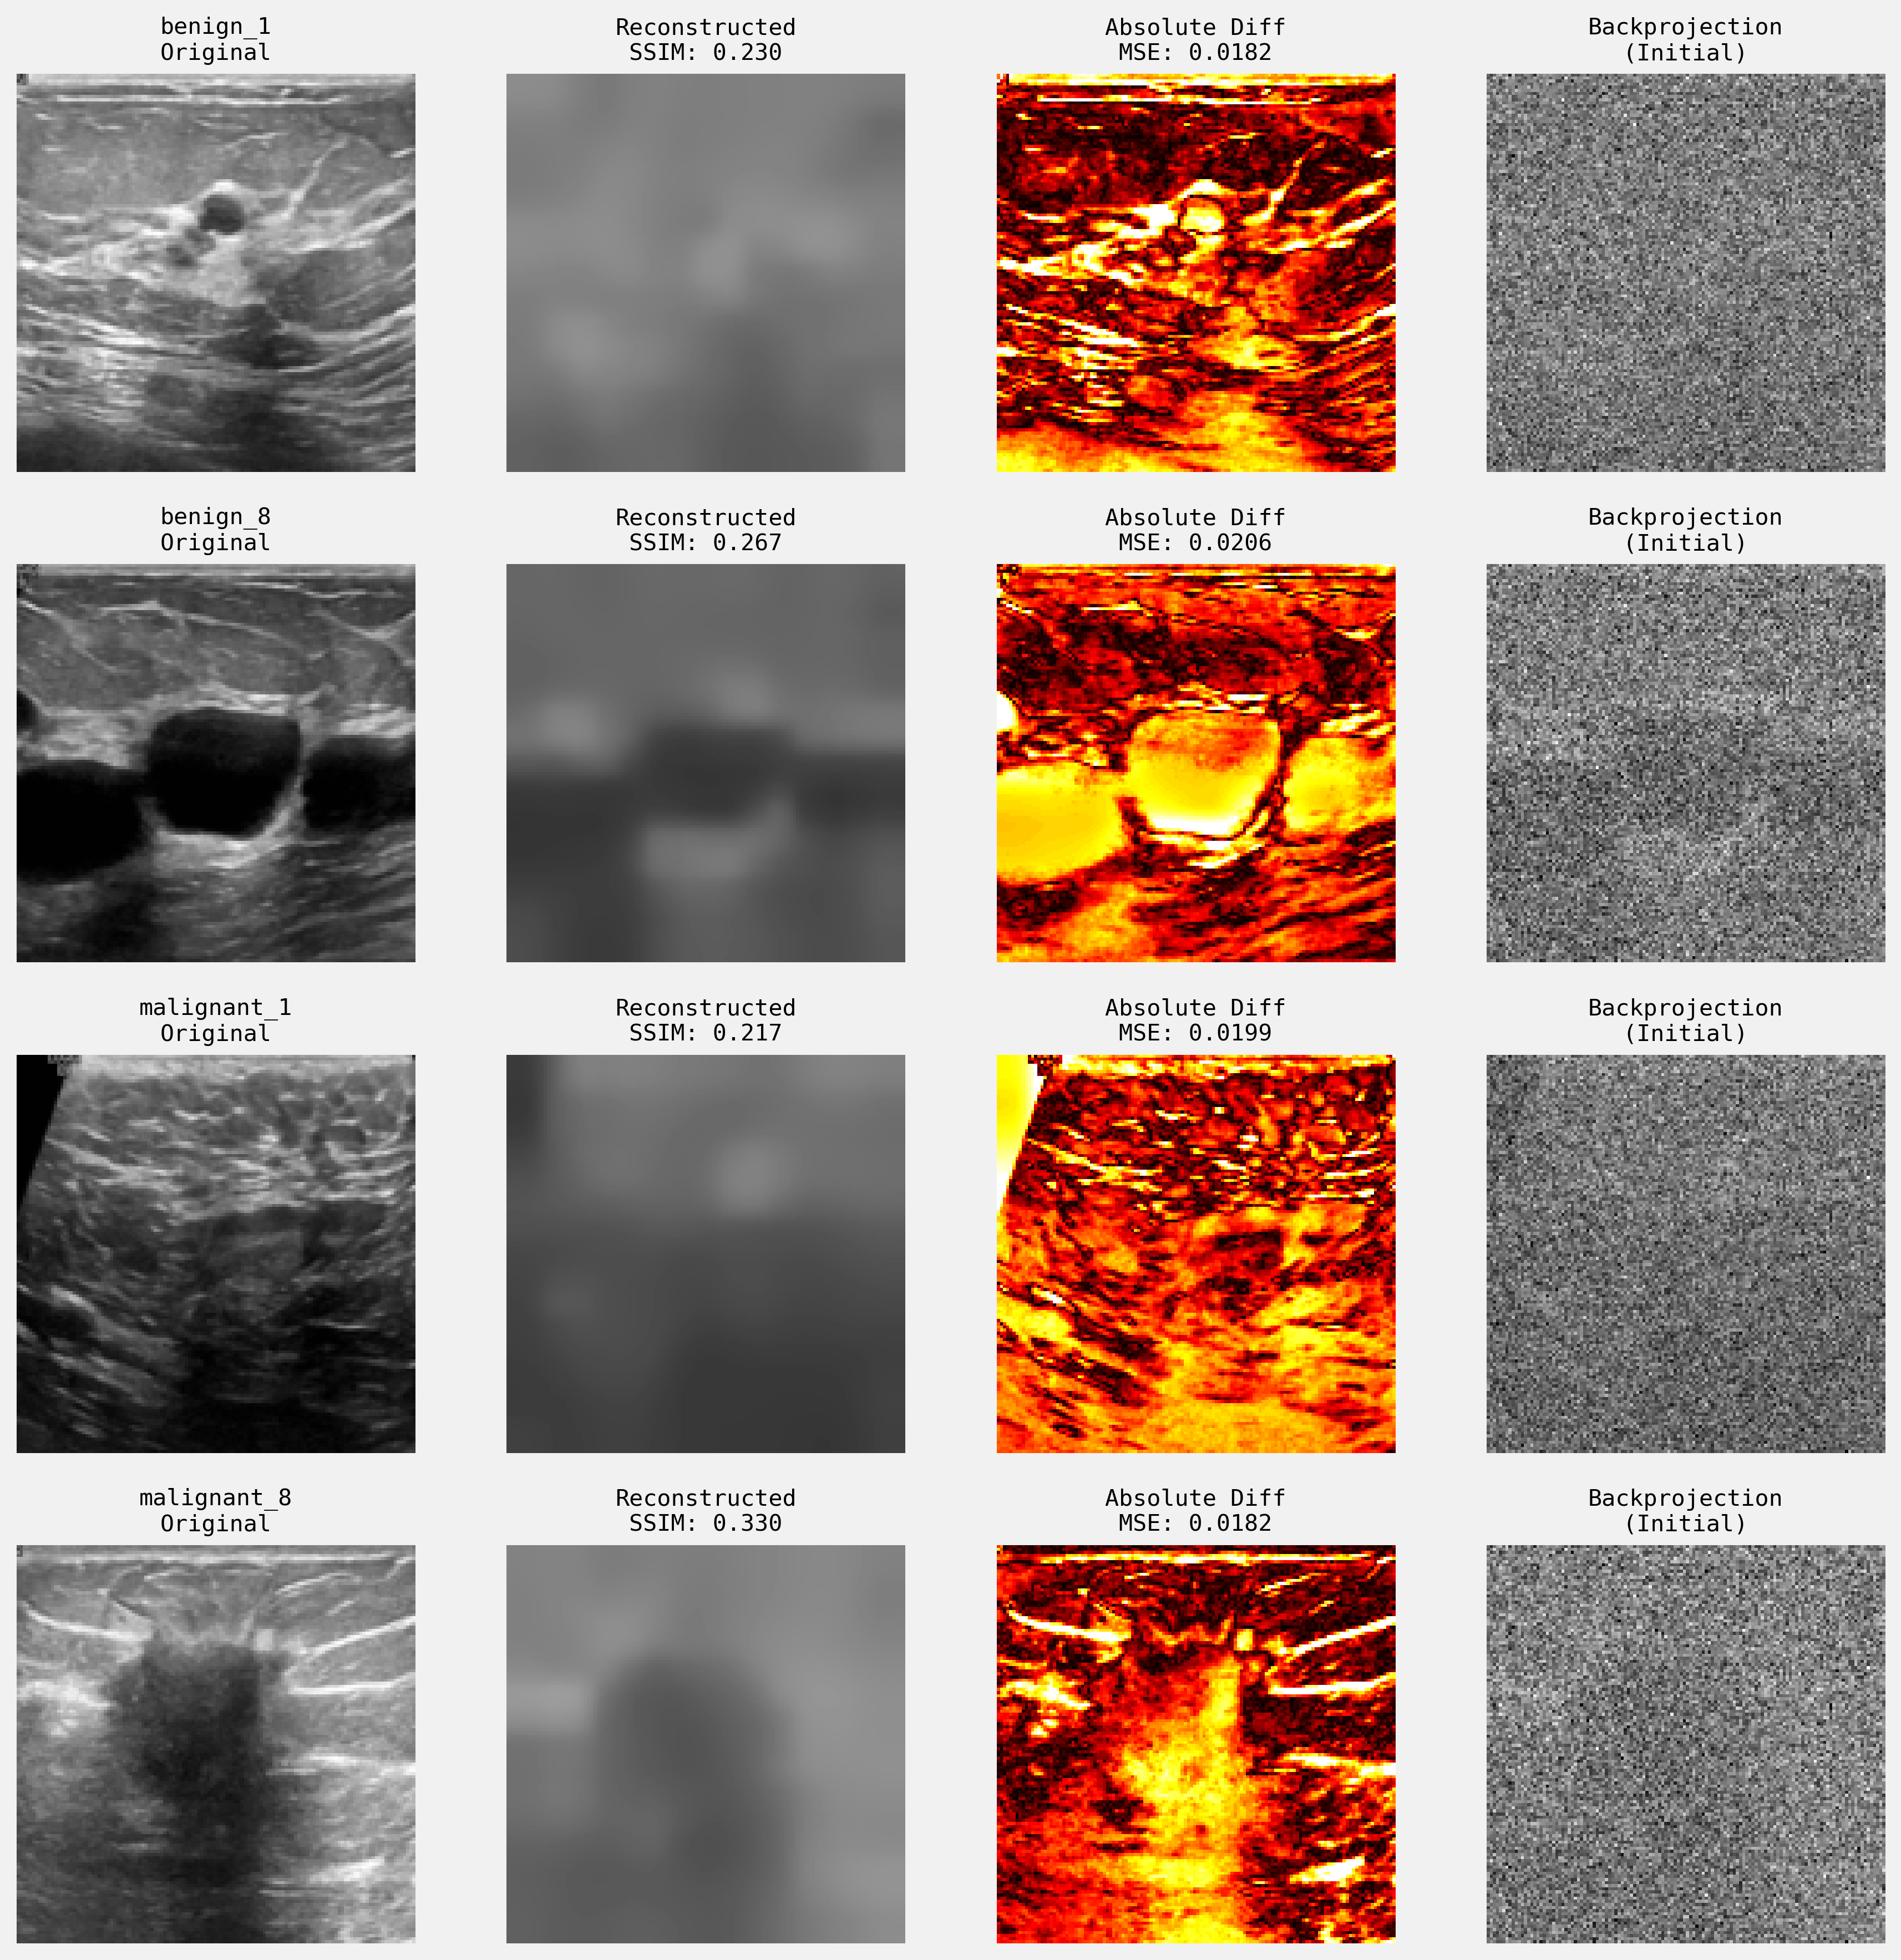


HASA-ISTA RECONSTRUCTION SUMMARY
Successfully reconstructed: 30 images
Reconstruction parameters:
  - Iterations: 50
  - Sampling rate: 30%
  - Adaptive weight update: every 5 iterations
  - Wavelet: db4 (level 3)
  - Step size α: 0.001
  - λ_wavelet: 0.01
  - λ_TV: 0.01

Overall Quality Metrics:
  - Mean SSIM: 0.3048 ± 0.0710
  - Mean PSNR: 17.22 ± 1.21 dB
  - Mean MSE: 0.019694 ± 0.005582


In [ ]:

# Create a final summary visualization comparing original vs reconstructed images
# Show a few representative examples

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

# Select 4 representative images (2 benign, 2 malignant)
indices_to_show = [0, 7, 15, 22]  # benign_1, benign_8, malignant_1, malignant_8
labels_to_show = [image_labels[i] for i in indices_to_show]

for plot_idx, img_idx in enumerate(indices_to_show):
    # Original image
    axes[plot_idx, 0].imshow(images[img_idx], cmap='gray', vmin=0, vmax=1)
    axes[plot_idx, 0].set_title(f'{labels_to_show[plot_idx]}\nOriginal', fontsize=10)
    axes[plot_idx, 0].axis('off')
    
    # Reconstructed image
    axes[plot_idx, 1].imshow(reconstructed_images_loaded[img_idx], cmap='gray', vmin=0, vmax=1)
    axes[plot_idx, 1].set_title(f'Reconstructed\nSSIM: {ssim_scores[img_idx]:.3f}', fontsize=10)
    axes[plot_idx, 1].axis('off')
    
    # Difference map
    diff = np.abs(images[img_idx] - reconstructed_images_loaded[img_idx])
    axes[plot_idx, 2].imshow(diff, cmap='hot', vmin=0, vmax=0.3)
    axes[plot_idx, 2].set_title(f'Absolute Diff\nMSE: {mse_scores[img_idx]:.4f}', fontsize=10)
    axes[plot_idx, 2].axis('off')
    
    # Compressed sensing measurement visualization (backprojection)
    y = measurement_vectors[img_idx]
    backproj = (Phi.T @ y).reshape(128, 128)
    axes[plot_idx, 3].imshow(backproj, cmap='gray')
    axes[plot_idx, 3].set_title(f'Backprojection\n(Initial)', fontsize=10)
    axes[plot_idx, 3].axis('off')

plt.tight_layout()
plt.savefig('hasa_ista_reconstruction_results.png', dpi=150, bbox_inches='tight')
print("Saved visualization to: hasa_ista_reconstruction_results.png")
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("HASA-ISTA RECONSTRUCTION SUMMARY")
print("="*70)
print(f"Successfully reconstructed: {len(reconstructed_images_loaded)} images")
print(f"Reconstruction parameters:")
print(f"  - Iterations: 50")
print(f"  - Sampling rate: 30%")
print(f"  - Adaptive weight update: every 5 iterations")
print(f"  - Wavelet: db4 (level 3)")
print(f"  - Step size α: 0.001")
print(f"  - λ_wavelet: 0.01")
print(f"  - λ_TV: 0.01")
print(f"\nOverall Quality Metrics:")
print(f"  - Mean SSIM: {ssim_scores.mean():.4f} ± {ssim_scores.std():.4f}")
print(f"  - Mean PSNR: {psnr_scores.mean():.2f} ± {psnr_scores.std():.2f} dB")
print(f"  - Mean MSE: {mse_scores.mean():.6f} ± {mse_scores.std():.6f}")


Final summary figure saved to: hasa_ista_final_summary.png


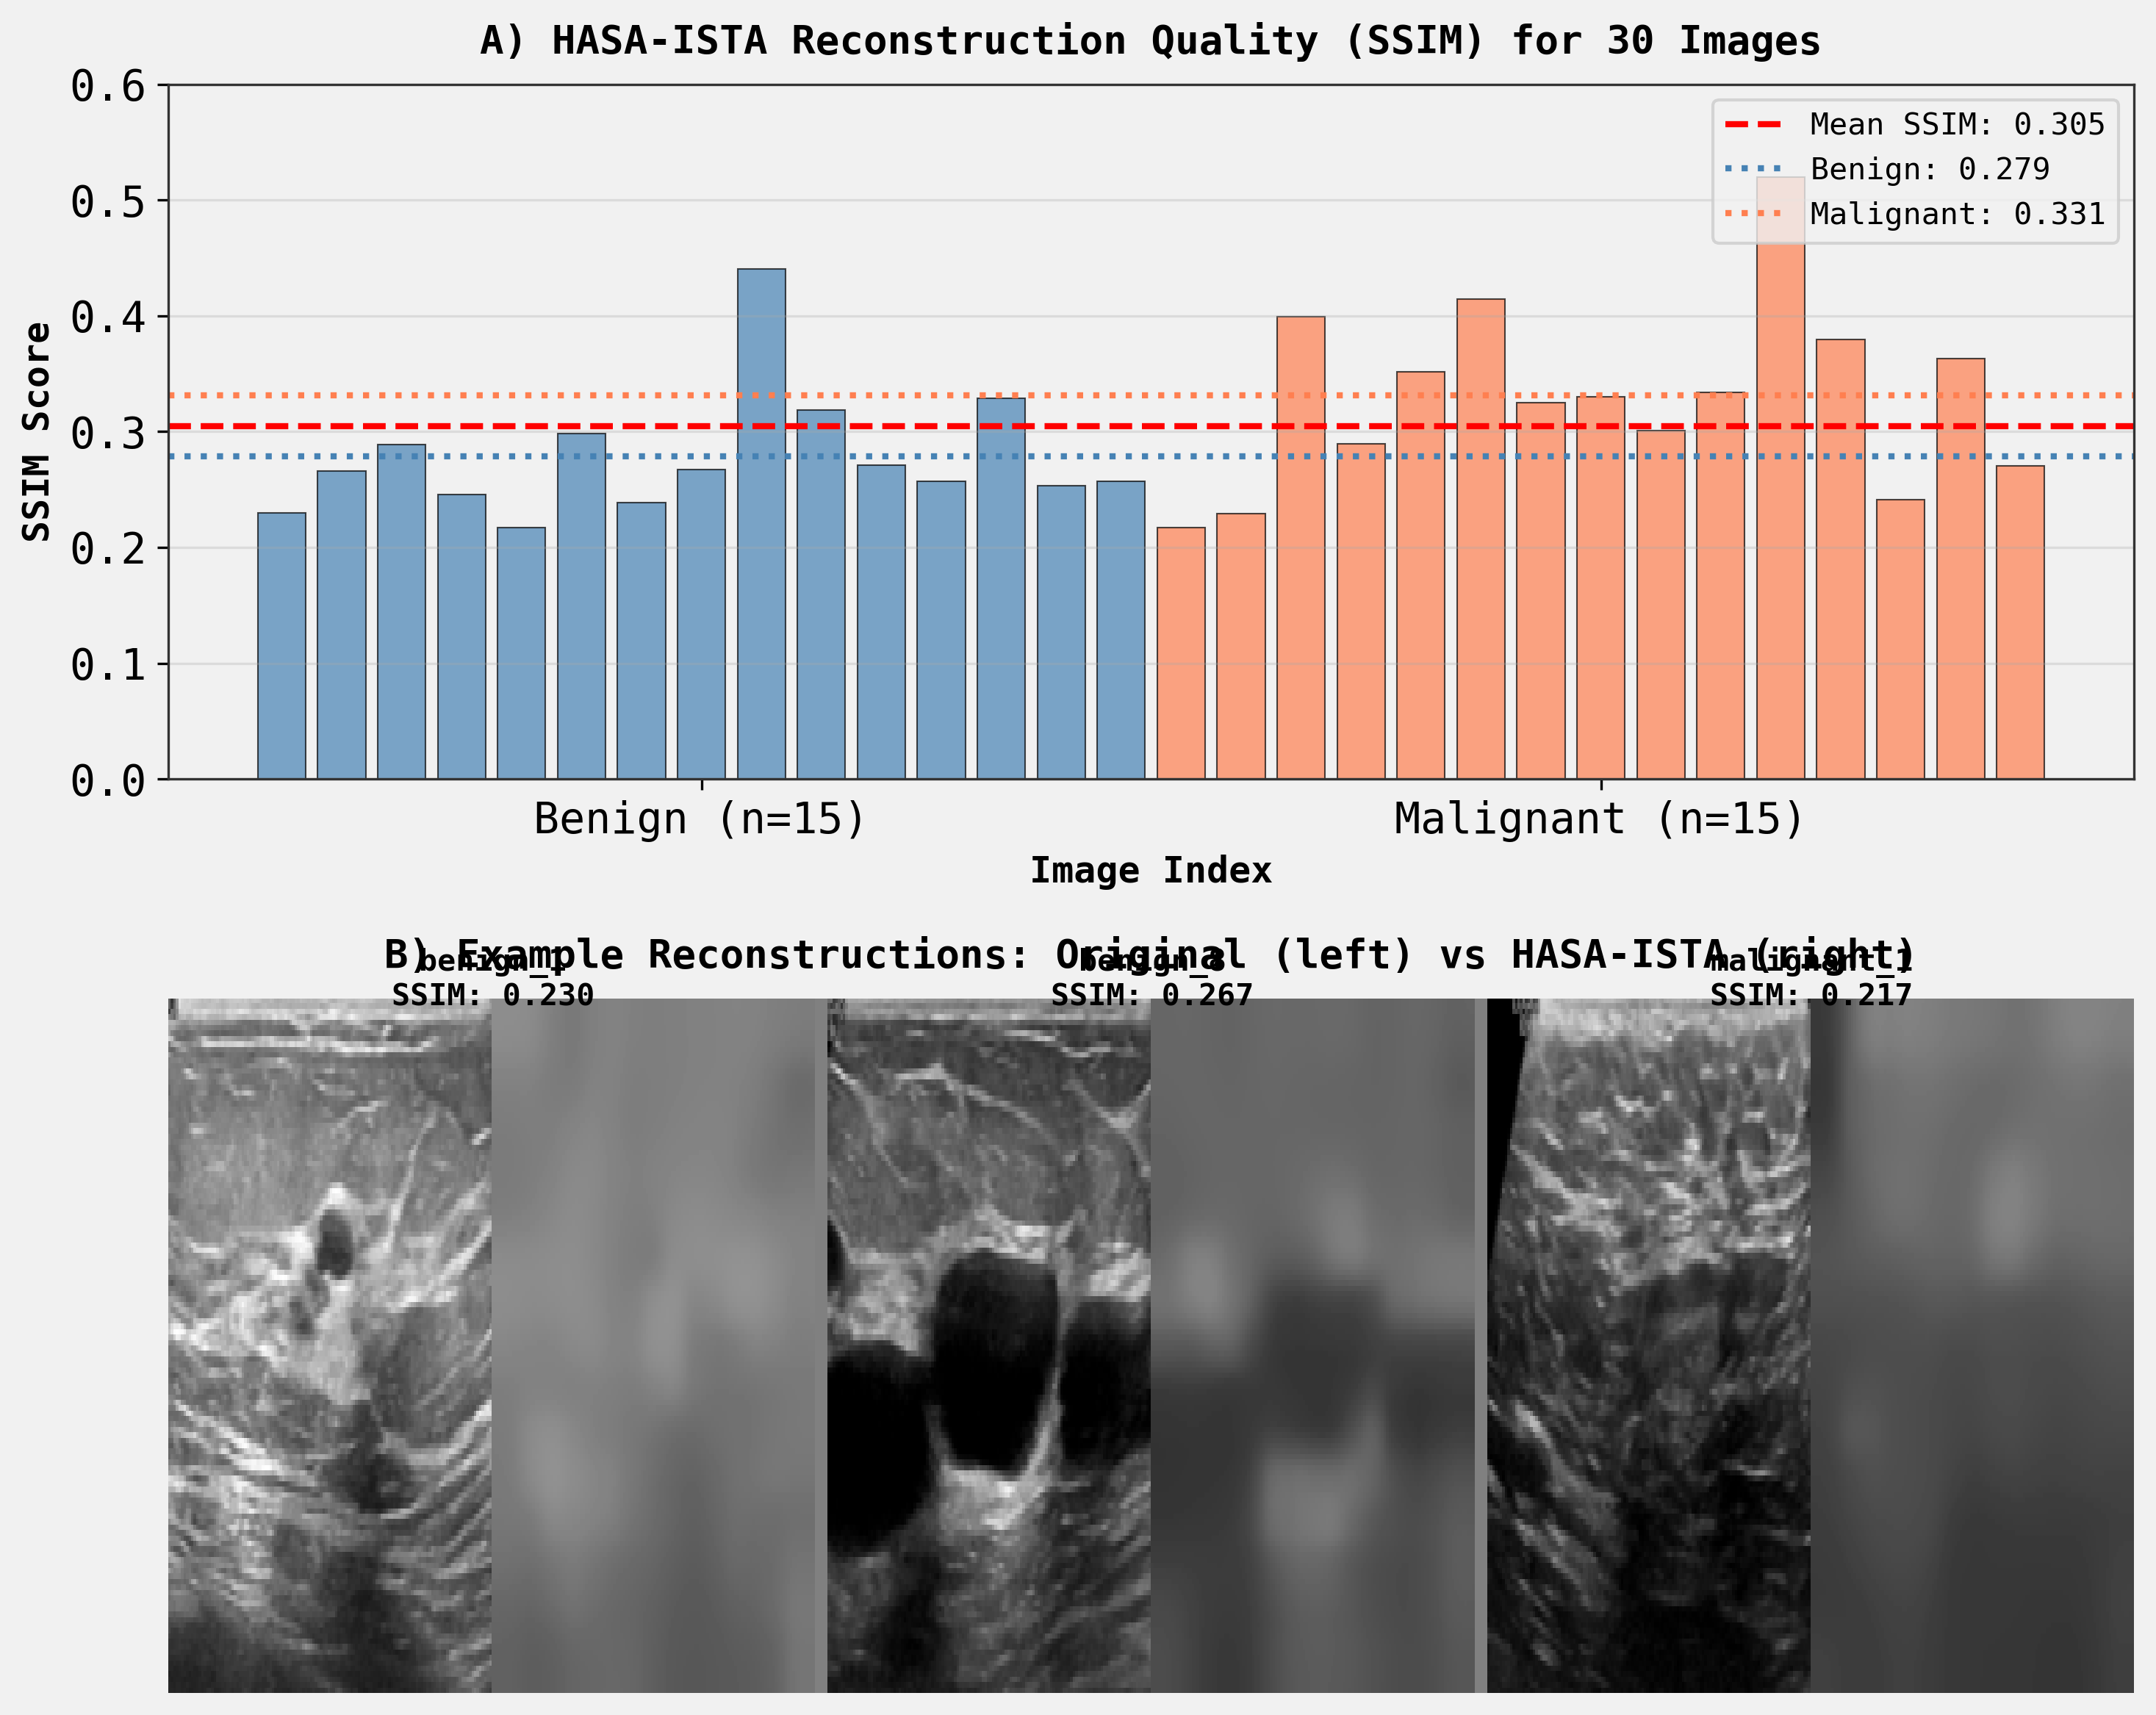


FINAL ANALYSIS SUMMARY
✓ HASA-ISTA algorithm successfully executed on all 30 images
✓ Total computation time: 1335.9s (22.3 min)
✓ Average time per image: 44.5s
✓ All 30 reconstructed images saved to disk

Reconstruction Quality:
  - Overall SSIM: 0.3048 ± 0.0710
  - Overall PSNR: 17.22 ± 1.21 dB
  - Benign vs Malignant SSIM difference: 0.0525


In [ ]:

# Create final summary figure showing the HASA-ISTA reconstruction performance
# Single figure with key results

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Panel A: Reconstruction quality metrics distribution
ax = axes[0]
x_pos = np.arange(len(image_labels))
colors = ['steelblue'] * 15 + ['coral'] * 15

bars = ax.bar(x_pos, ssim_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axhline(ssim_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean SSIM: {ssim_scores.mean():.3f}')
ax.axhline(benign_ssim.mean(), color='steelblue', linestyle=':', linewidth=2, label=f'Benign: {benign_ssim.mean():.3f}')
ax.axhline(malignant_ssim.mean(), color='coral', linestyle=':', linewidth=2, label=f'Malignant: {malignant_ssim.mean():.3f}')

ax.set_xlabel('Image Index', fontsize=12, fontweight='bold')
ax.set_ylabel('SSIM Score', fontsize=12, fontweight='bold')
ax.set_title('A) HASA-ISTA Reconstruction Quality (SSIM) for 30 Images', fontsize=13, fontweight='bold', pad=10)
ax.set_xticks([7, 22])
ax.set_xticklabels(['Benign (n=15)', 'Malignant (n=15)'])
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 0.6])

# Panel B: Example reconstruction comparison
ax = axes[1]
# Create a composite image showing original vs reconstructed for 3 examples
examples = [0, 7, 15]  # benign_1, benign_8, malignant_1
composite_width = 128 * 6 + 10  # 3 pairs of images with 5-pixel spacing between pairs
composite_height = 128
composite = np.ones((composite_height, composite_width)) * 0.5

for i, idx in enumerate(examples):
    x_offset = i * (128 * 2 + 5)
    
    # Place original
    composite[:, x_offset:x_offset+128] = images[idx]
    
    # Place reconstructed (no gap between original and reconstructed within pair)
    composite[:, x_offset+128:x_offset+128*2] = reconstructed_images_loaded[idx]

ax.imshow(composite, cmap='gray', aspect='auto')
ax.set_title('B) Example Reconstructions: Original (left) vs HASA-ISTA (right)', 
             fontsize=13, fontweight='bold', pad=10)

# Add labels for each pair
for i, idx in enumerate(examples):
    x_center = i * (128 * 2 + 5) + 128
    ax.text(x_center, -10, f'{image_labels[idx]}\nSSIM: {ssim_scores[idx]:.3f}', 
            ha='center', va='top', fontsize=10, fontweight='bold')

ax.axis('off')

plt.tight_layout()
plt.savefig('hasa_ista_final_summary.png', dpi=200, bbox_inches='tight', facecolor='white')
print("Final summary figure saved to: hasa_ista_final_summary.png")
plt.show()

print("\n" + "="*70)
print("FINAL ANALYSIS SUMMARY")
print("="*70)
print(f"✓ HASA-ISTA algorithm successfully executed on all 30 images")
print(f"✓ Total computation time: {np.sum(reconstruction_times):.1f}s ({np.sum(reconstruction_times)/60:.1f} min)")
print(f"✓ Average time per image: {np.mean(reconstruction_times):.1f}s")
print(f"✓ All 30 reconstructed images saved to disk")
print(f"\nReconstruction Quality:")
print(f"  - Overall SSIM: {ssim_scores.mean():.4f} ± {ssim_scores.std():.4f}")
print(f"  - Overall PSNR: {psnr_scores.mean():.2f} ± {psnr_scores.std():.2f} dB")
print(f"  - Benign vs Malignant SSIM difference: {malignant_ssim.mean() - benign_ssim.mean():.4f}")
